In [6]:
import json
import pathlib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

from common import (
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    save_fig,
    qps_median_ci,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)

# Toggle to show/hide point ID annotations on scatter plots.
ANNOTATE_POINT_IDS = False


def compute_qps(metrics: dict) -> tuple[float, float, float]:
    """Compute (median_qps, lo_err, hi_err) from serial_latencies via bootstrap."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return qps_median_ci(latencies)


def get_arxiv_dataset_order(entry: dict) -> str:
    """Return the dataset order variant for an ArxivFilter result entry.

    Supports both the new 'arxiv_dataset_order' field and the legacy
    'sorted_by_update_date' boolean for backward compatibility.
    """
    custom = entry["task_config"]["case_config"].get("custom_case", {})
    # New-style: explicit string field
    order = custom.get("arxiv_dataset_order")
    if order is not None:
        return order
    # Legacy: boolean sorted_by_update_date
    if custom.get("sorted_by_update_date", False):
        return "sorted_by_update_date"
    return "original"


def lighten(color, amount=0.45):
    """Mix *color* toward white by *amount* (0 = unchanged, 1 = white)."""
    r, g, b, a = mcolors.to_rgba(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount, a)


# ---------------------------------------------------------------------------
# Dataset order definitions for comparison plots.
# Each entry: (key in records_by_order, legend suffix, linestyle, lighten_amount, zorder_base)
# Toggle entries on/off by commenting them out.
# ---------------------------------------------------------------------------
DATASET_ORDERS = [
    # ("original",              "original",  "--", 0.15, 5),
    ("randomly_shuffled",     "random",    ":",  0.30, 1),
    ("sorted_by_update_date", "sorted",    "-",  0.00, 9),
]


FILTER_TYPE_TITLES = {
    "EM": "Exact Match (EM)\n$\\mathit{int\\_col = 3}$",
    "R": "Range (R)\n$\\mathit{int\\_col\\ BETWEEN\\ start\\ AND\\ end}$",
    "EMIS": "Exact Match In Set (EMIS)\n$\\mathit{list\\_contains(string\\_list\\_col,\\ 'abc')}$",
}

FILTER_TYPE_ORDER = ["EM", "R", "EMIS"]

# ---------------------------------------------------------------------------
# 1. Load all result JSONs from the index_filtered_search results directory
# ---------------------------------------------------------------------------
# records_by_order: "original" | "sorted_by_update_date" | "randomly_shuffled" → list of records
records_by_order: dict[str, list[dict]] = {
    "original": [],
    "sorted_by_update_date": [],
    "randomly_shuffled": [],
}

# Legacy aliases kept for backward compatibility with later cells
records = records_by_order["original"]
records_sorted = records_by_order["sorted_by_update_date"]

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_filtered_search_arxiv/DuckDB")
duckdb_json_files = sorted(
    p for p in duckdb_results_dir.glob("*.json") if not p.name.startswith("muted_")
)

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Skip blob-interface results
        if db_case_cfg.get("use_blob_interface", False):
            continue

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type is None:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        _qps = compute_qps(metrics)
        record = {
            "recall": metrics["recall"],
            "serial_qps": _qps[0],
            "serial_qps_lo": _qps[1],
            "serial_qps_hi": _qps[2],
            "index": index_name,
            "filter_type": filter_type,
            "db_type": "DuckDB",
            "source_file": str(path),
        }

        order = get_arxiv_dataset_order(entry)
        if order in records_by_order:
            records_by_order[order].append(record)

# Load pgvector results (if available)
pgvector_results_dir = pathlib.Path("../experiments/results/index_filtered_search_arxiv/pgvector")
pgvector_json_files = sorted(
    p for p in pgvector_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type is None:
            continue

        index_name = transform_pgvector_index_name(db_case_cfg)

        _qps = compute_qps(metrics)
        record = {
            "recall": metrics["recall"],
            "serial_qps": _qps[0],
            "serial_qps_lo": _qps[1],
            "serial_qps_hi": _qps[2],
            "index": index_name,
            "filter_type": filter_type,
            "db_type": "pgvector",
            "source_file": str(path),
        }

        order = get_arxiv_dataset_order(entry)
        if order in records_by_order:
            records_by_order[order].append(record)

for order_name, recs in records_by_order.items():
    if recs:
        print(f"Loaded {len(recs):>4d} {order_name} results")
print(f"  from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded   67 original results
  from 0 DuckDB files and 67 pgvector files


[{'recall': 0.859,
  'serial_qps': 724.1785100027156,
  'serial_qps_lo': 15.253088339401529,
  'serial_qps_hi': 16.909046719129606,
  'index': 'pgvector (HNSW)',
  'filter_type': 'EM',
  'db_type': 'pgvector',
  'source_file': '../experiments/results/index_filtered_search_arxiv/pgvector/result_20260311_pgvectorhnsw_ArxivFilterPerformanceCase_22-32-39_pgvector.json'},
 {'recall': 0.8765,
  'serial_qps': 680.6001395910887,
  'serial_qps_lo': 17.67150651015436,
  'serial_qps_hi': 17.525159533188912,
  'index': 'pgvector (HNSW)',
  'filter_type': 'EM',
  'db_type': 'pgvector',
  'source_file': '../experiments/results/index_filtered_search_arxiv/pgvector/result_20260311_pgvectorhnsw_ArxivFilterPerformanceCase_22-32-45_pgvector.json'},
 {'recall': 0.8941,
  'serial_qps': 671.1125636969712,
  'serial_qps_lo': 18.216123509725207,
  'serial_qps_hi': 18.15710495815256,
  'index': 'pgvector (HNSW)',
  'filter_type': 'EM',
  'db_type': 'pgvector',
  'source_file': '../experiments/results/index_fil

In [7]:
# ---------------------------------------------------------------------------
# 2. Determine filter types present in data
# ---------------------------------------------------------------------------

# Filter types to exclude from all plots. Comment/uncomment to toggle.
EXCLUDE_FILTER_TYPES = set([
    # "EM",
    # "R",
    # "EMIS",
])

filter_types = [ft for ft in FILTER_TYPE_ORDER if ft not in EXCLUDE_FILTER_TYPES and any(r["filter_type"] == ft for r in records)]
print(f"Filter types: {filter_types}")
if EXCLUDE_FILTER_TYPES:
    print(f"Excluded: {EXCLUDE_FILTER_TYPES}")

Filter types: ['EM', 'R', 'EMIS']


In [8]:
# ---------------------------------------------------------------------------
# 2b. Assign point IDs and print lookup table (when ANNOTATE_POINT_IDS is True).
#     Toggle ANNOTATE_POINT_IDS at the top of the first cell.
# ---------------------------------------------------------------------------

for i, r in enumerate(records):
    r["point_id"] = i

if ANNOTATE_POINT_IDS:
    print(f"{'ID':>4}  {'Recall':>7}  {'QPS':>8}  {'Index':45s}  {'File'}")
    print("-" * 120)
    for r in records:
        src = pathlib.Path(r["source_file"]).name
        print(f"{r['point_id']:>4}  {r['recall']:>7.4f}  {r['serial_qps']:>8.1f}  "
              f"{r['index']:45s}  {src}")
else:
    print("Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.")


Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.


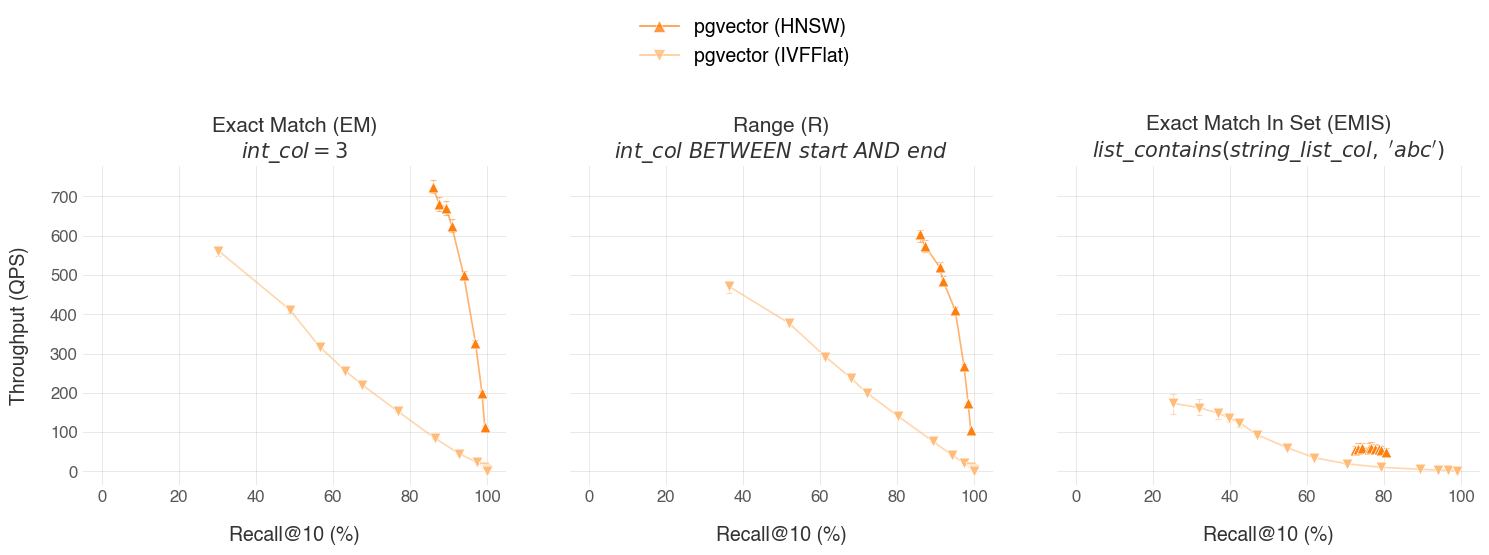

In [9]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS, one subplot per filter type
# ---------------------------------------------------------------------------

# ONLY THE ORIGINAL DATA.

from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Group records: filter_type → index_type → list of (recall, qps) tuples
grouped: dict[str, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))

for r in records:
    grouped[r["filter_type"]][r["index"]].append((r["recall"], r["serial_qps"], r["serial_qps_lo"], r["serial_qps_hi"], r.get("point_id", -1)))

# Get all unique index types present in the data, in canonical order
all_index_types = set()
for ft in filter_types:
    all_index_types.update(grouped[ft].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

# Create subplots: one per filter type (1 row, 3 cols)
n_plots = len(filter_types)
fig, axes = plt.subplots(1, n_plots, figsize=(5.0 * n_plots, 5.0), squeeze=False, sharey=True)

for ft_idx, ft in enumerate(filter_types):
    ax = axes[0][ft_idx]

    for index_type in all_index_types:
        points = grouped[ft].get(index_type, [])
        if not points:
            continue

        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]
        qps_lo = [p[2] for p in points]
        qps_hi = [p[3] for p in points]

        point_ids = [p[4] for p in points]

        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")
        z_scatter = 10 if index_type == "DuckDB" else 3
        z_line = 9 if index_type == "DuckDB" else 2

        ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                   ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=z_scatter)
        ax.scatter(recalls, qps_vals, label=index_type, color=color,
                   marker=marker, s=MARKER_SIZE, zorder=z_scatter, edgecolors='white', linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=z_line)
        if ANNOTATE_POINT_IDS:
            for _r, _q, _pid in zip(recalls, qps_vals, point_ids):
                ax.annotate(str(_pid), (_r, _q), fontsize=5, ha="left", va="bottom",
                            color="#333333", xytext=(3, 3), textcoords="offset points", zorder=10)

    title = FILTER_TYPE_TITLES.get(ft, ft)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
    if ft_idx == 0:
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # ax.set_yscale("log")
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([i / 5 for i in range(6)])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Shared legend across all subplots
legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=math.ceil(len(all_index_types) / 2),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(wspace=0.15)
save_fig("index_filtered_search_arxiv")

# Save y-axis limits so the sorted-by-update-date plot can match
shared_ylim = axes[0][0].get_ylim()

# Plots only original dataset variant.

Selectivity bucket ranges (4 buckets):
  B0: 0%–5%  (15 queries)
  B1: 5%–25%  (222 queries)
  B2: 25%–75%  (673 queries)
  B3: 75%–100%  (90 queries)


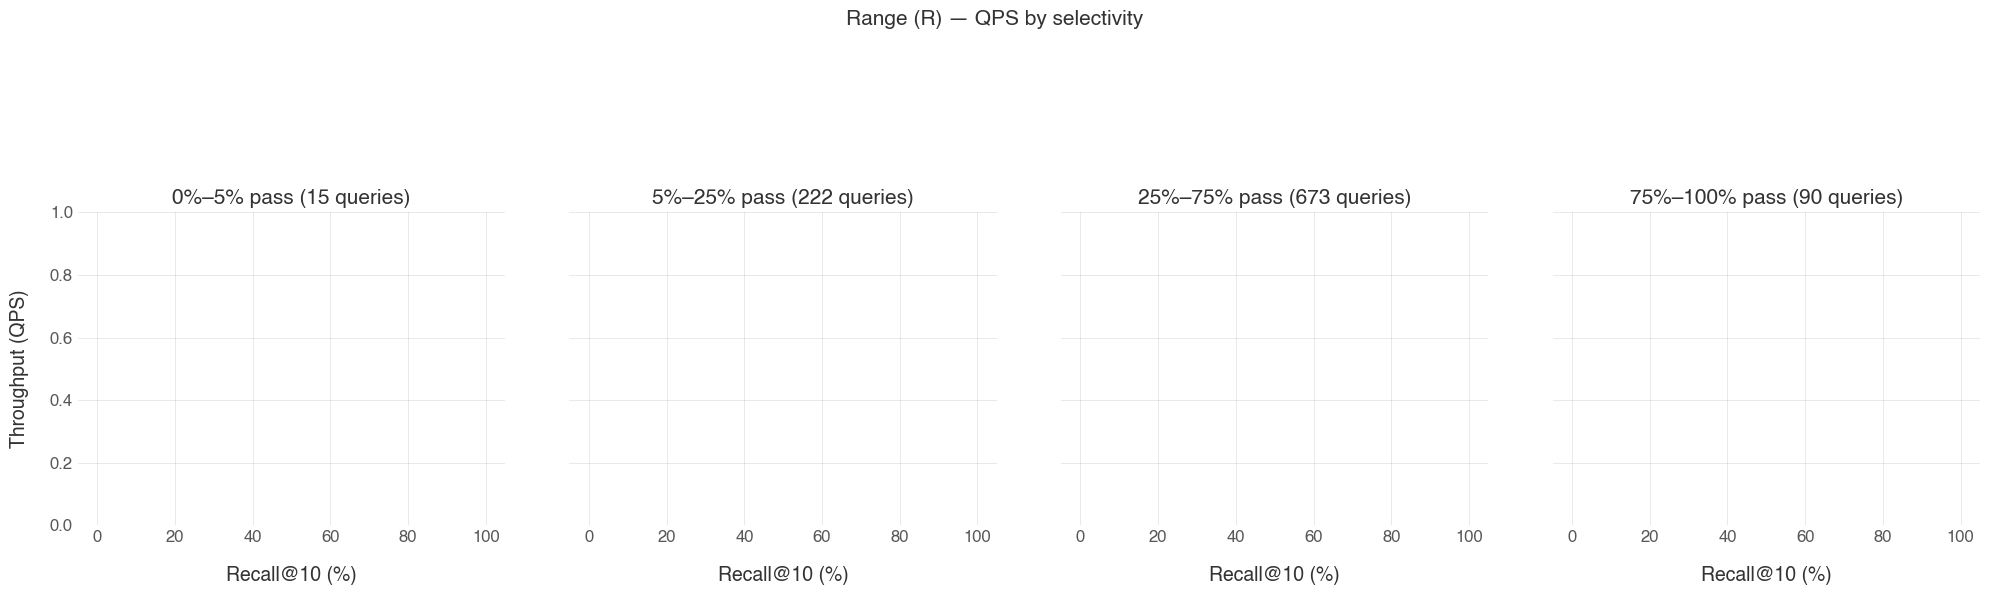

In [10]:
# ---------------------------------------------------------------------------
# 5. Range (R) QPS by selectivity bucket — all dataset orders
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Custom selectivity bucket ranges (percentage of rows that pass the filter).
# Each tuple is (low_pct, high_pct) — queries whose selectivity falls in
# [low_pct/100, high_pct/100) are assigned to that bucket.
# The last bucket uses a closed upper bound.
BUCKET_RANGES = [
    (0, 5),
    (5, 25),
    (25, 75),
    (75, 100),
]
NUM_BUCKETS = len(BUCKET_RANGES)

# Load per-query selectivities from the precomputed JSON
with open("arxiv_range_selectivity.json") as f:
    sel_data = json.load(f)

# Selectivities for the first max_search_queries (1000) test queries
MAX_QUERIES = 1000
query_selectivities = np.array([q["selectivity"] for q in sel_data["queries"][:MAX_QUERIES]])

# Assign each query to a bucket based on the custom ranges
bucket_assignment = np.full(MAX_QUERIES, -1, dtype=int)
for b, (lo, hi) in enumerate(BUCKET_RANGES):
    lo_frac, hi_frac = lo / 100.0, hi / 100.0
    if b == NUM_BUCKETS - 1:
        # Last bucket: closed upper bound
        mask = (query_selectivities >= lo_frac) & (query_selectivities <= hi_frac)
    else:
        mask = (query_selectivities >= lo_frac) & (query_selectivities < hi_frac)
    bucket_assignment[mask] = b

# Report bucket stats
bucket_counts = []
print(f"Selectivity bucket ranges ({NUM_BUCKETS} buckets):")
for b, (lo, hi) in enumerate(BUCKET_RANGES):
    count = int((bucket_assignment == b).sum())
    bucket_counts.append(count)
    print(f"  B{b}: {lo}%–{hi}%  ({count} queries)")

unassigned = int((bucket_assignment == -1).sum())
if unassigned > 0:
    print(f"  WARNING: {unassigned} queries not assigned to any bucket")

# ---------------------------------------------------------------------------
# Re-process raw result JSONs to extract per-query latencies for Range (R)
# ---------------------------------------------------------------------------
def compute_bucket_qps(latencies: list[float], bucket_assignment: np.ndarray, num_buckets: int) -> list[tuple[float, float, float]]:
    """Given per-query latencies and bucket assignments, return (qps, lo_err, hi_err) per bucket."""
    lats = np.array(latencies)
    qps_per_bucket = []
    for b in range(num_buckets):
        mask = bucket_assignment == b
        bucket_lats = lats[mask]
        if len(bucket_lats) == 0:
            qps_per_bucket.append((0.0, 0.0, 0.0))
        else:
            qps_per_bucket.append(qps_median_ci(bucket_lats.tolist()))
    return qps_per_bucket


# Records per bucket per dataset order:
#   order_key → list[bucket_idx → dict[index_name → list[(recall, qps)]]]
bucket_records_by_order: dict[str, list[dict[str, list[tuple[float, float]]]]] = {}
active_order_keys = {key for key, _, _, _, _ in DATASET_ORDERS}
for order_key in active_order_keys:
    bucket_records_by_order[order_key] = [defaultdict(list) for _ in range(NUM_BUCKETS)]

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Skip blob-interface results. Note should not be necessary.
        if db_case_cfg.get("use_blob_interface", False):
            continue

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type != "R":
            continue

        latencies = metrics.get("serial_latencies", [])
        if len(latencies) != MAX_QUERIES:
            continue

        order = get_arxiv_dataset_order(entry)
        if order not in active_order_keys:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)
        index_name = transform_duckdb_index_name(db_case_cfg, global_version)
        recall = metrics["recall"]

        qps_list = compute_bucket_qps(latencies, bucket_assignment, NUM_BUCKETS)
        for b in range(NUM_BUCKETS):
            bucket_records_by_order[order][b][index_name].append((recall, qps_list[b][0], qps_list[b][1], qps_list[b][2]))

# Process pgvector results
for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_type = custom.get("arxiv_filter_type")
        if filter_type != "R":
            continue

        latencies = metrics.get("serial_latencies", [])
        if len(latencies) != MAX_QUERIES:
            continue

        order = get_arxiv_dataset_order(entry)
        if order not in active_order_keys:
            continue

        index_name = transform_pgvector_index_name(db_case_cfg)
        recall = metrics["recall"]

        qps_list = compute_bucket_qps(latencies, bucket_assignment, NUM_BUCKETS)
        for b in range(NUM_BUCKETS):
            bucket_records_by_order[order][b][index_name].append((recall, qps_list[b][0], qps_list[b][1], qps_list[b][2]))

# ---------------------------------------------------------------------------
# Plot: NUM_BUCKETS subplots, one per selectivity bucket
# ---------------------------------------------------------------------------
all_idx_q = set()
for order_key in active_order_keys:
    for b in range(NUM_BUCKETS):
        all_idx_q.update(bucket_records_by_order[order_key][b].keys())
all_idx_q = [idx for idx in INDEX_ORDER if idx in all_idx_q]

fig, axes = plt.subplots(1, NUM_BUCKETS, figsize=(5.0 * NUM_BUCKETS, 5.0), squeeze=False, sharey=True)

for b in range(NUM_BUCKETS):
    ax = axes[0][b]
    lo, hi = BUCKET_RANGES[b]

    for order_key, _, linestyle, lighten_amount, z_base in DATASET_ORDERS:
        bucket_data = bucket_records_by_order[order_key][b]
        for index_type in all_idx_q:
            points = bucket_data.get(index_type, [])
            if not points:
                continue
            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]
            qps_lo = [p[2] for p in points]
            qps_hi = [p[3] for p in points]

            color = lighten(index_colors.get(index_type, "#808080"), lighten_amount)
            marker = index_markers.get(index_type, "o")
            ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                       ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=z_base + 1)
            ax.scatter(recalls, qps_vals, color=color, marker=marker, s=MARKER_SIZE,
                       zorder=z_base + 1, edgecolors="white", linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6,
                       linestyle=linestyle, zorder=z_base)

    ax.set_title(f"{lo}%–{hi}% pass ({bucket_counts[b]} queries)", fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
    if b == 0:
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([i / 5 for i in range(6)])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))
    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Shared legend
legend_handles = []
for index_type in all_idx_q:
    base_color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    for order_key, label_suffix, linestyle, lighten_amount, _ in DATASET_ORDERS:
        # Only add legend entry if this combination has data in any bucket
        has_data = any(bucket_records_by_order[order_key][b].get(index_type) for b in range(NUM_BUCKETS))
        if not has_data:
            continue
        color = lighten(base_color, lighten_amount)
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle=linestyle,
                                      markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                      linewidth=1.2, alpha=0.8, label=f"{index_type} ({label_suffix})"))

if legend_handles:
    fig.legend(handles=legend_handles, loc="upper center", ncol=min(4, len(legend_handles)),
               frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.12))

fig.suptitle(f"Range (R) — QPS by selectivity", fontsize=TITLE_FONTSIZE, color=FONT_COLOR, y=1.18)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(wspace=0.15)
save_fig("index_filtered_search_arxiv_by_selectivity")